In [1]:
"""Demo notebook: spectra and frequency-domain filtering of the images in pics/."""

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from filters import CircleFilter, LineFilter
from image_handler import ImageHandler

In [2]:
def padKernal(width, length, kernel):
    """Zero-pad `kernel` to length x width, keeping it centred."""
    xL = length - len(kernel)
    xW = width - len(kernel[0])
    wPadLeft = xW // 2
    wPadRight = xW - wPadLeft
    lPadUp = xL // 2
    lPadDown = xL - lPadUp
    npad = ((lPadUp, lPadDown), (wPadLeft, wPadRight))
    return np.pad(kernel, pad_width=npad, mode="constant", constant_values=0)


def show_real(img):
    """Display the spatial-domain image."""
    plt.figure()
    plt.imshow(img.image, cmap="gray")
    plt.title("Image")
    plt.axis("off")
    plt.show()


def show_fft(img):
    """Display the log power spectrum (DC at the centre)."""
    psd2D = np.log(np.abs(img.four) ** 2 + 1)
    plt.figure()
    plt.imshow(psd2D, cmap="gray")
    plt.title("Fourier")
    plt.axis("off")
    plt.show()


def show_real_fft(img):
    """Display the image followed by its spectrum."""
    show_real(img)
    show_fft(img)

case  0


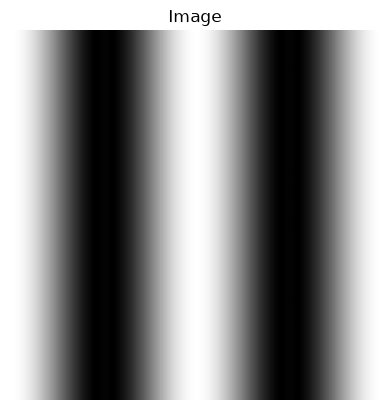

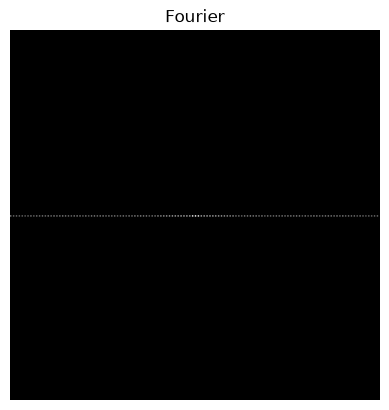

case  1


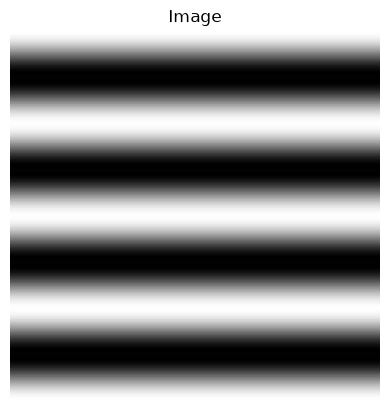

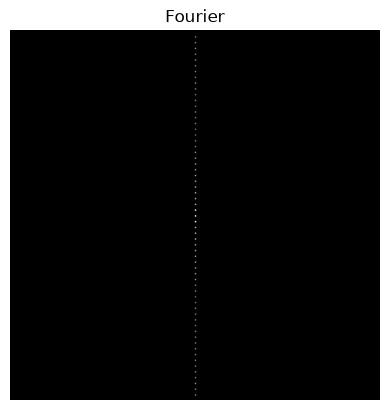

case  2


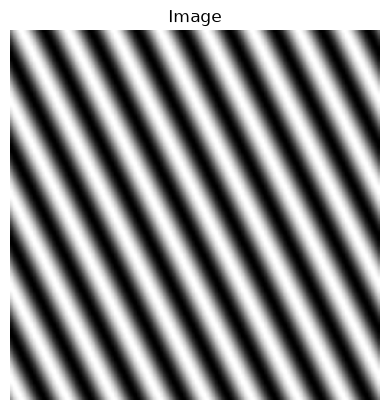

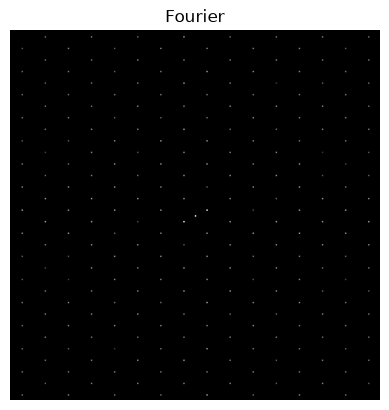

case  3


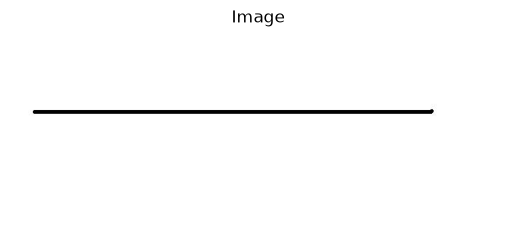

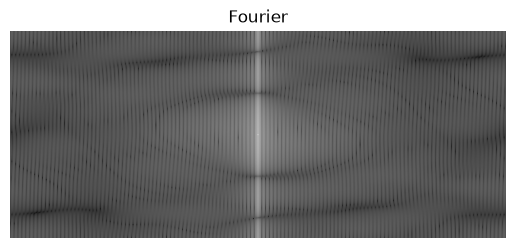

case  4


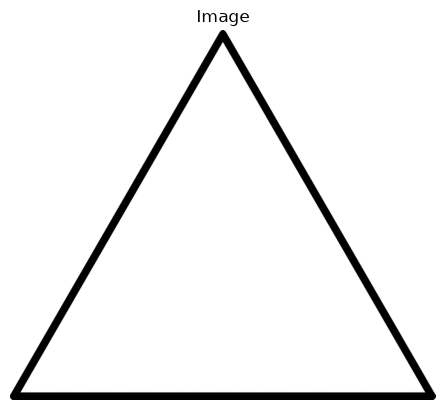

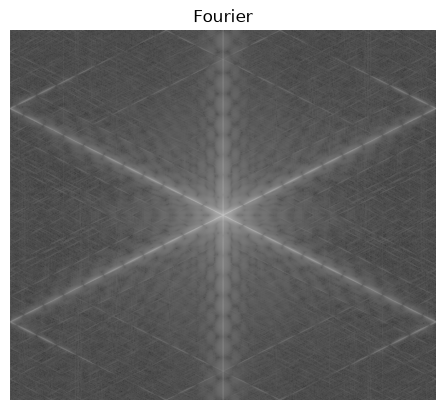

case  5


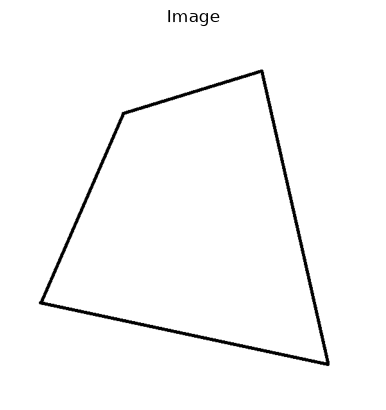

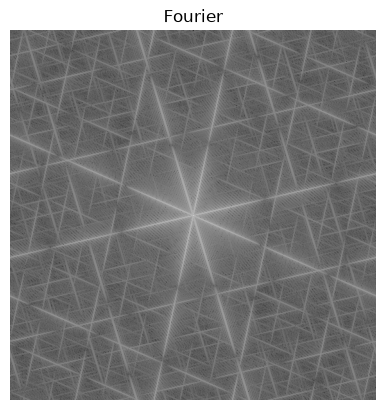

case  6


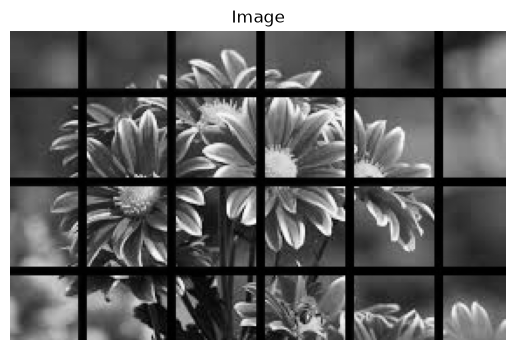

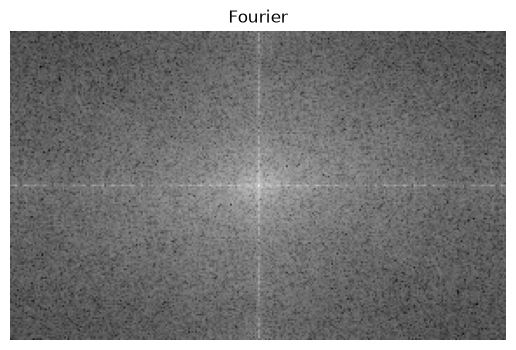

case  7


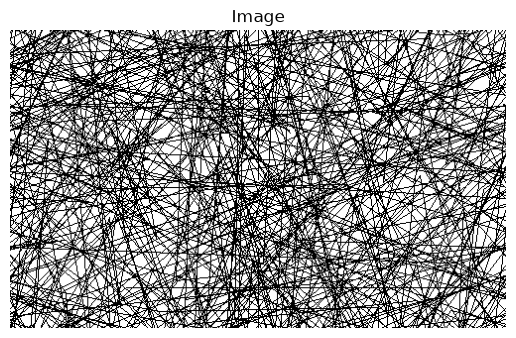

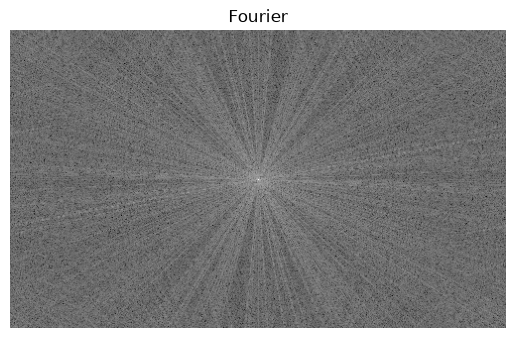

case  8


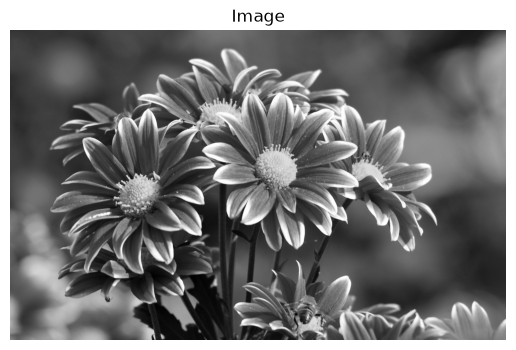

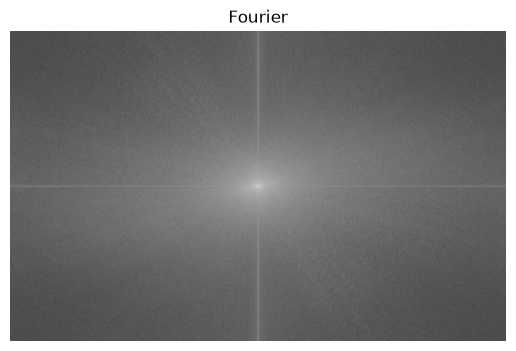

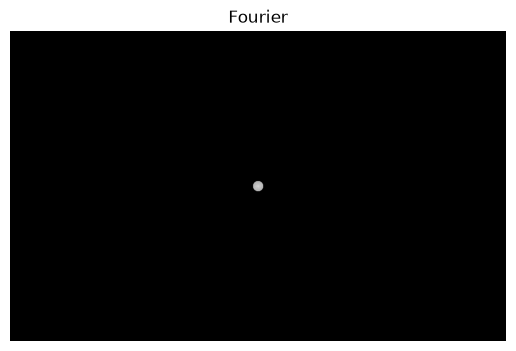

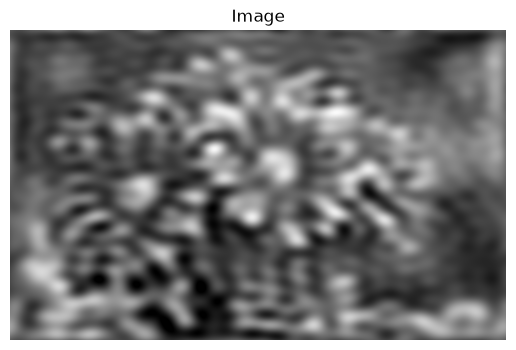

case  9


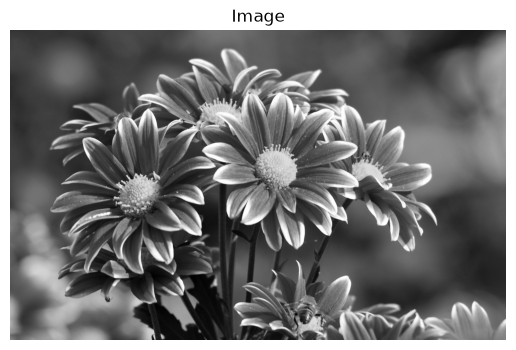

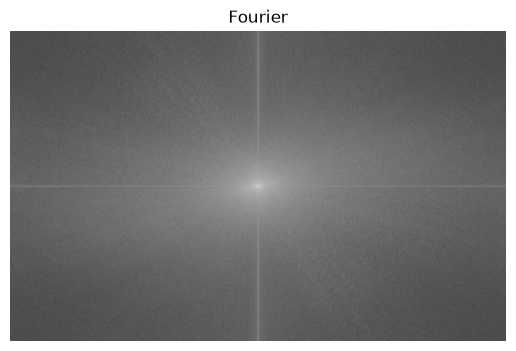

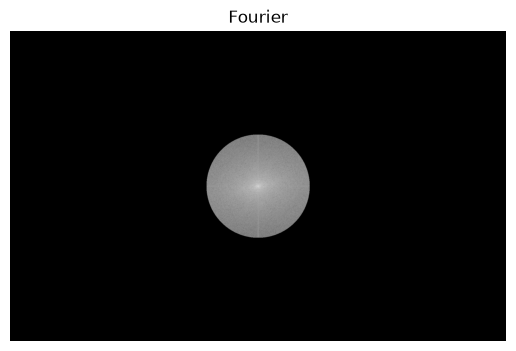

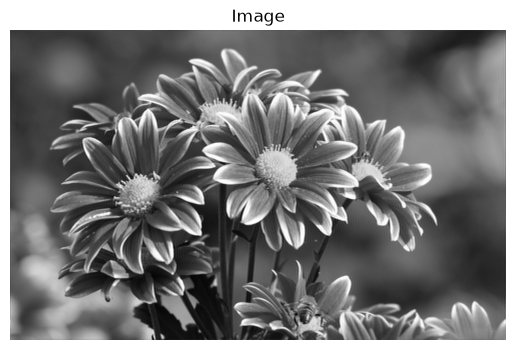

case  10


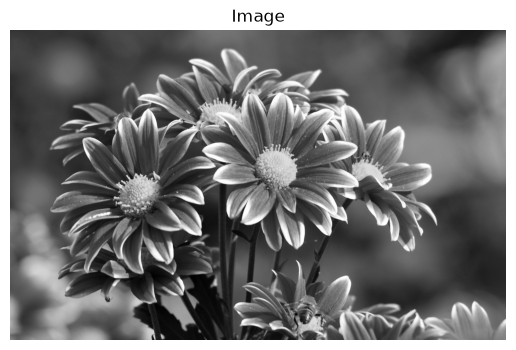

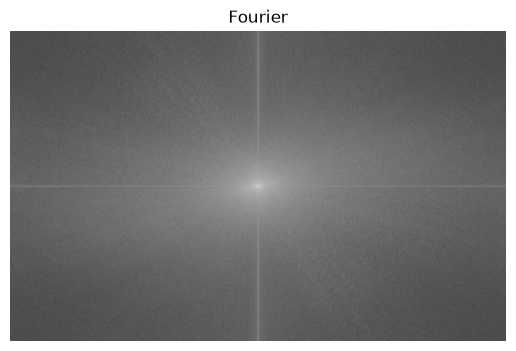

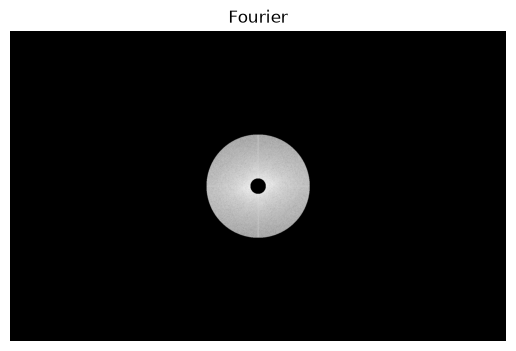

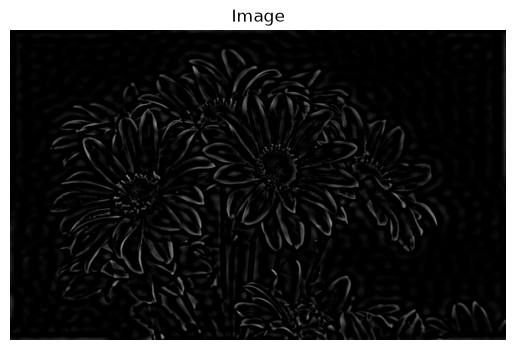

case  11


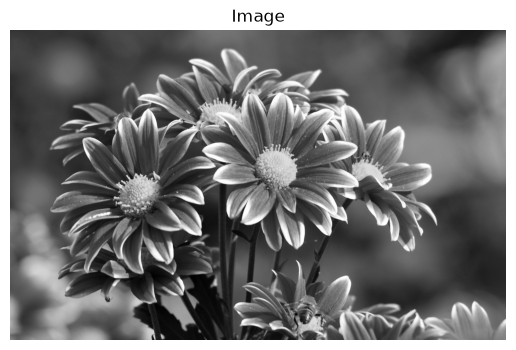

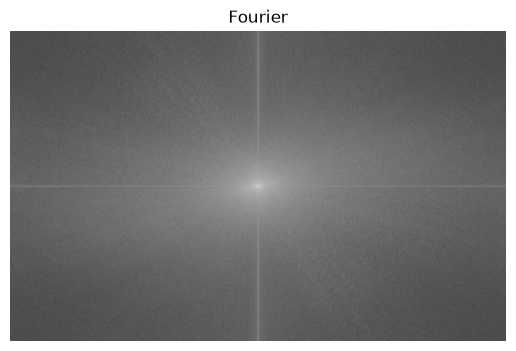

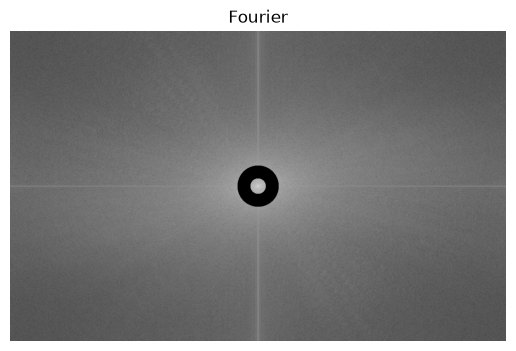

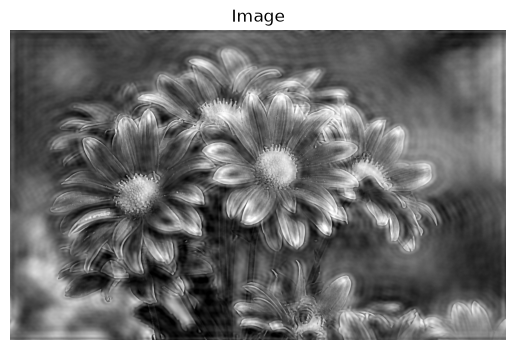

case  12


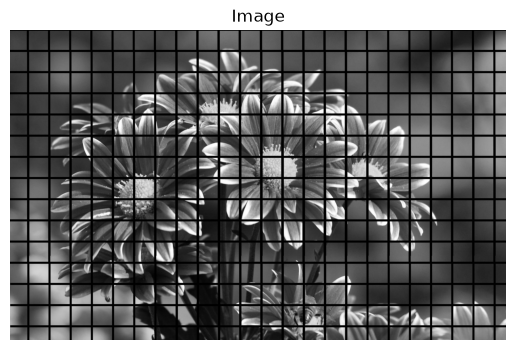

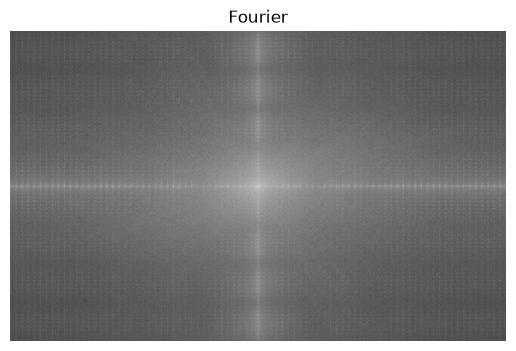

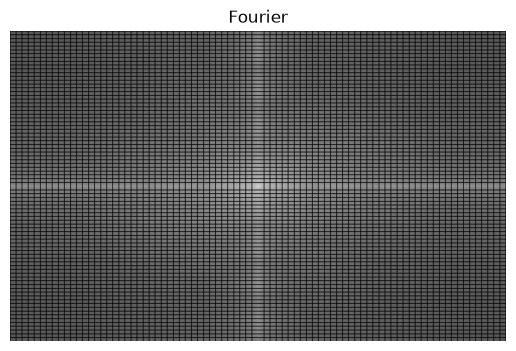

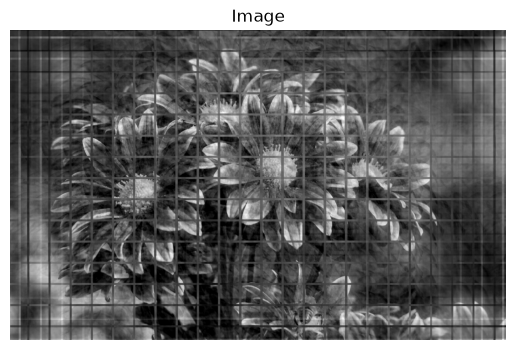

case  13


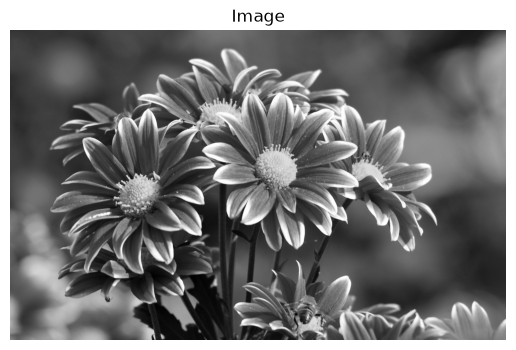

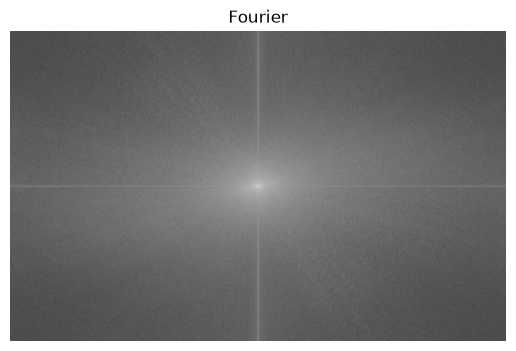

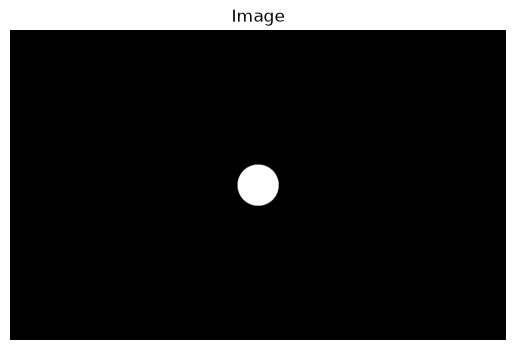

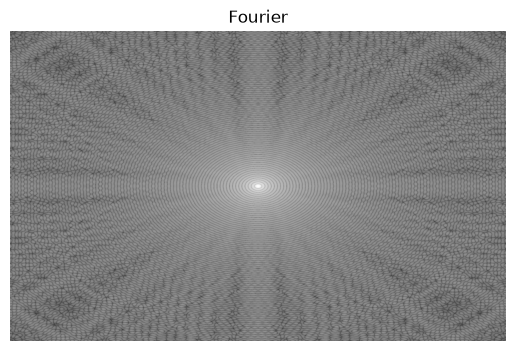

In [3]:
# Cases that only show the image and its spectrum.
PLAIN_CASES = {
    0: "pics/vertsine.gif",
    1: "pics/sin4h.gif",
    2: "pics/diagonalsine.jpg",
    3: "pics/s2.jpg",
    4: "pics/s3.jpg",
    5: "pics/s4.png",
    6: "pics/flowers8.jpg",
    7: "pics/lines2.gif",
}

# Cases that apply a circular filter to flowersHD.jpg.
CIRCLE_CASES = {
    8: CircleFilter(20, outside=False),
    9: CircleFilter(200, outside=False),
    10: CircleFilter(30, 200, outside=False),
    11: CircleFilter(30, 80, outside=True),
}


def run_case(run_code):
    """Run one numbered experiment."""
    if run_code in PLAIN_CASES:
        show_real_fft(ImageHandler(PLAIN_CASES[run_code]))

    elif run_code in CIRCLE_CASES:
        im = ImageHandler("pics/flowersHD.jpg")
        show_real_fft(im)
        im.applyFilter(CIRCLE_CASES[run_code])
        show_fft(im)
        show_real(im)

    elif run_code == 12:
        # Zero out lines in the spectrum (skipping line 41, the centre) to remove the periodic grid.
        im = ImageHandler("pics/flowersgray.jpg")
        show_real_fft(im)

        (height, width) = im.four.shape
        line_filter = LineFilter(width, height)
        for i in range(83):
            if i != 41:
                line_filter.addLine(int(23.41 * i) - 1, 0, int(23.41 * i) - 1, 1200, 3)
        for i in range(83):
            if i != 41:
                line_filter.addLine(0, int(14.65 * i) - 1, 1920, int(14.65 * i) - 1, 3)
        im.applyFilter(line_filter)

        show_fft(im)
        show_real(im)

    elif run_code == 13:
        # Use the low-pass mask itself as the image, then view its spectrum.
        im = ImageHandler("pics/flowersHD.jpg")
        show_real_fft(im)

        bigH = CircleFilter(80, outside=False).showMultImage(im.four)
        im2 = ImageHandler("pics/flowersHD.jpg")
        im2.image = Image.fromarray((bigH * 255).astype(np.uint8))
        im2.four = im2.fourier()

        show_real_fft(im2)
        im2.inverseFourier()


if __name__ == "__main__":
    for run_code in range(14):
        print("case ", run_code)
        run_case(run_code)